In [1]:
print("EDA Notebook Ready")


EDA Notebook Ready


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

plt.style.use("default")
sns.set_theme(style="whitegrid")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [3]:
funds = pd.read_csv("../data/processed/fund_master_clean.csv")

nav = pd.read_csv("../data/processed/nav_history_clean.csv")

aum = pd.read_csv("../data/processed/aum_by_fund_house_clean.csv")

sip = pd.read_csv("../data/processed/monthly_sip_inflows_clean.csv")

category = pd.read_csv("../data/processed/category_inflows_clean.csv")

folio = pd.read_csv("../data/processed/industry_folio_count_clean.csv")

performance = pd.read_csv("../data/processed/scheme_performance_clean.csv")

transactions = pd.read_csv("../data/processed/investor_transactions_clean.csv")

holdings = pd.read_csv("../data/processed/portfolio_holdings_clean.csv")

benchmark = pd.read_csv("../data/processed/benchmark_indices_clean.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [4]:
print("Funds:", funds.shape)
print("NAV:", nav.shape)
print("AUM:", aum.shape)
print("Transactions:", transactions.shape)

Funds: (40, 15)
NAV: (46000, 3)
AUM: (90, 5)
Transactions: (32778, 13)


In [5]:
# Convert date column

nav["date"] = pd.to_datetime(nav["date"])

# Merge fund names

nav_plot = nav.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

print(nav_plot.head())

   amfi_code       date      nav                                scheme_name
0     119551 2022-01-03  54.3856  SBI Bluechip Fund - Regular Plan - Growth
1     119551 2022-01-04  54.3474  SBI Bluechip Fund - Regular Plan - Growth
2     119551 2022-01-05  54.6869  SBI Bluechip Fund - Regular Plan - Growth
3     119551 2022-01-06  55.4550  SBI Bluechip Fund - Regular Plan - Growth
4     119551 2022-01-07  55.3692  SBI Bluechip Fund - Regular Plan - Growth


In [6]:
import plotly.express as px

fig = px.line(
    nav_plot,
    x="date",
    y="nav",
    color="scheme_name",
    title="Daily NAV Trend of All Mutual Fund Schemes (2022–2026)"
)

fig.update_layout(
    height=700,
    legend_title="Scheme"
)

fig.show()

In [7]:
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    annotation_text="2023 Bull Run",
    fillcolor="green",
    opacity=0.15,
    line_width=0
)

fig.add_vrect(
    x0="2024-01-01",
    x1="2024-06-30",
    annotation_text="2024 Market Correction",
    fillcolor="red",
    opacity=0.15,
    line_width=0
)

fig.show()

In [8]:
fig.write_html("../reports/nav_trend_analysis.html")

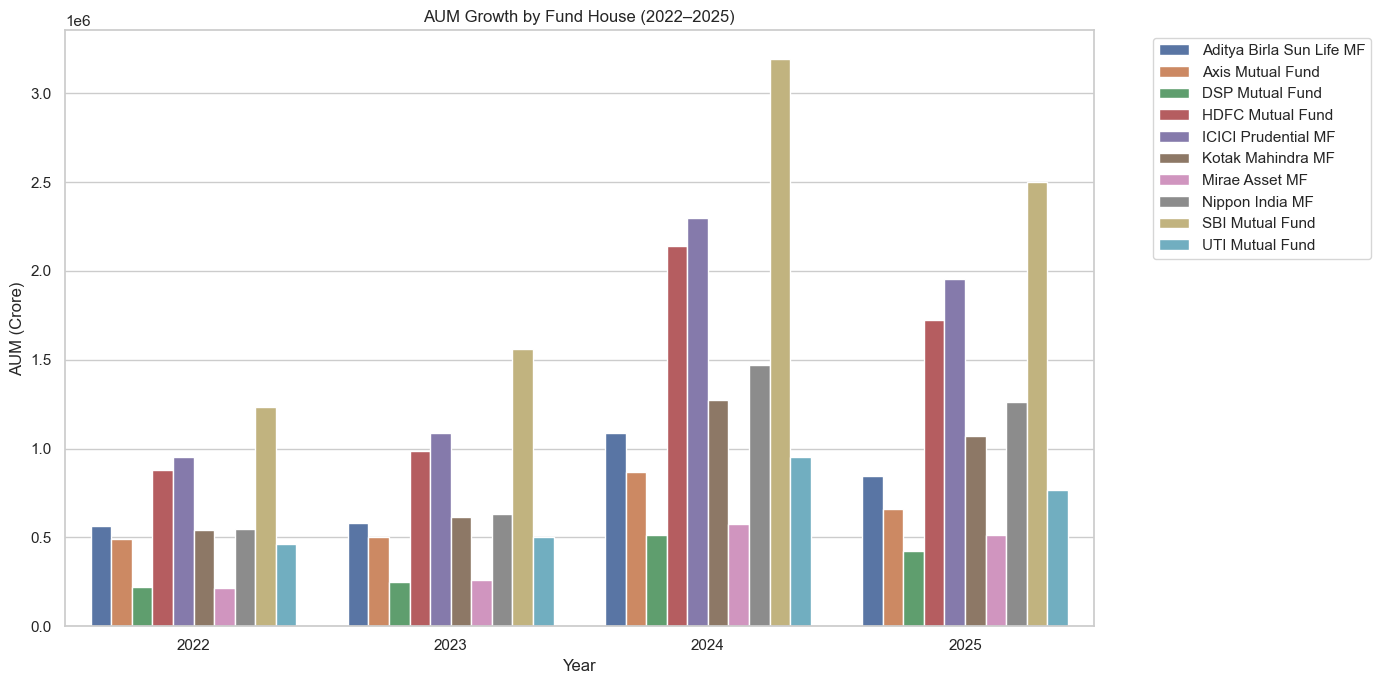

In [9]:
# AUM Growth Analysis

import seaborn as sns
import matplotlib.pyplot as plt

# Convert date
aum["date"] = pd.to_datetime(aum["date"])

# Extract year
aum["year"] = aum["date"].dt.year

# Aggregate AUM by fund house and year
aum_yearly = (
    aum.groupby(["year", "fund_house"])["aum_crore"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=0)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [10]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum_yearly,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.tight_layout()

plt.savefig(
    "../reports/aum_growth.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("AUM chart saved successfully")

AUM chart saved successfully


In [11]:
import os

os.listdir("../reports")

['aum_growth.png', 'nav_trend_analysis.html']

In [12]:
# SIP Trend Analysis

sip["month"] = pd.to_datetime(sip["month"])

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022–2025)",
    markers=True
)

max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text=f"Peak SIP: ₹{max_row['sip_inflow_crore']:,.0f} Cr",
    showarrow=True
)

fig.show()

In [13]:
fig.write_html("../reports/sip_trend.html")

print("SIP chart saved successfully")

SIP chart saved successfully


In [14]:
import os
os.listdir("../reports")

['aum_growth.png', 'nav_trend_analysis.html', 'sip_trend.html']

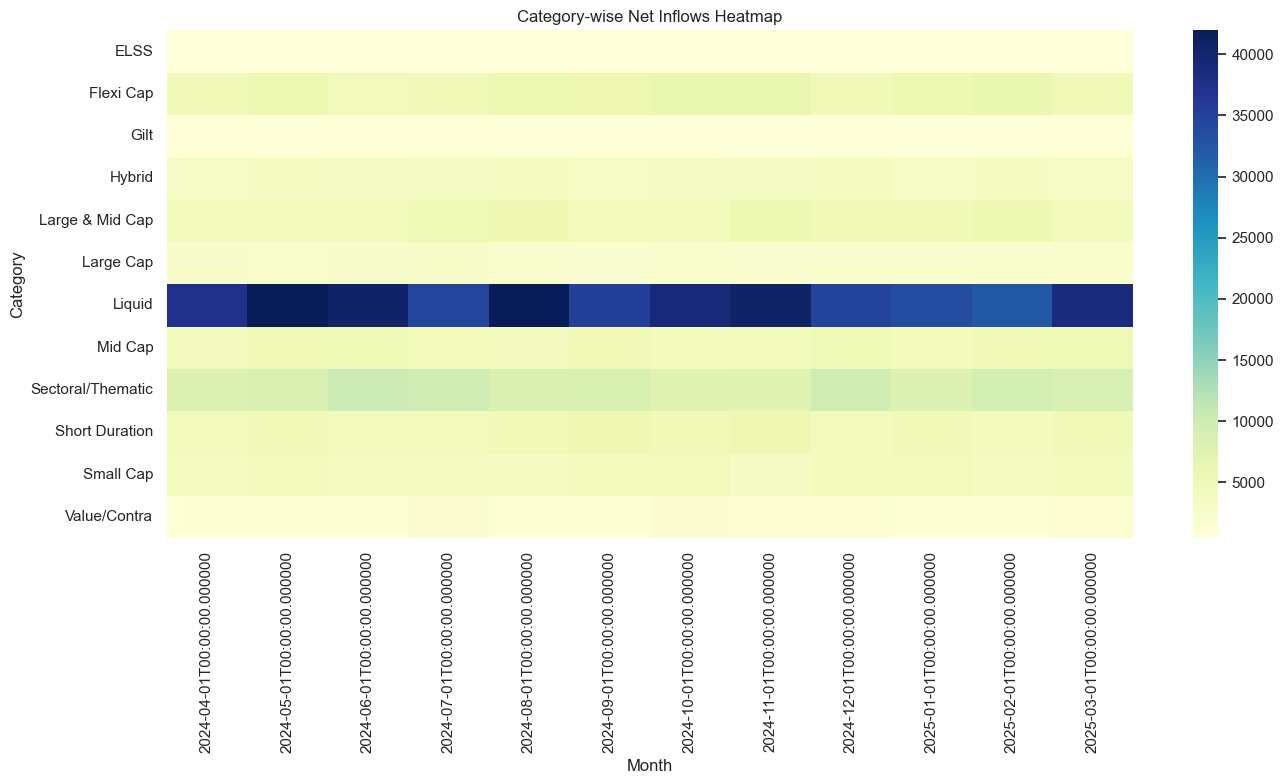

In [15]:
# Category Inflow Heatmap

category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    annot=False
)

plt.title("Category-wise Net Inflows Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

plt.show()

In [16]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title("Category-wise Net Inflows Heatmap")

plt.tight_layout()

plt.savefig(
    "../reports/category_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Category heatmap saved successfully")

Category heatmap saved successfully


In [17]:
import os
os.listdir("../reports")

['aum_growth.png',
 'category_heatmap.png',
 'nav_trend_analysis.html',
 'sip_trend.html']

In [18]:
# Investor Age Group Distribution

age_counts = (
    transactions["age_group"]
    .value_counts()
    .reset_index()
)

age_counts.columns = ["age_group", "count"]

fig = px.pie(
    age_counts,
    names="age_group",
    values="count",
    title="Investor Age Group Distribution"
)

fig.show()

In [19]:
fig.write_html("../reports/investor_age_distribution.html")

print("Investor age chart saved successfully")

Investor age chart saved successfully


In [20]:
# Gender Distribution

gender_counts = (
    transactions["gender"]
    .value_counts()
    .reset_index()
)

gender_counts.columns = ["gender", "count"]

fig = px.pie(
    gender_counts,
    names="gender",
    values="count",
    title="Gender Distribution of Investors"
)

fig.show()

In [21]:
fig.write_html("../reports/gender_distribution.html")

print("Gender chart saved successfully")

Gender chart saved successfully


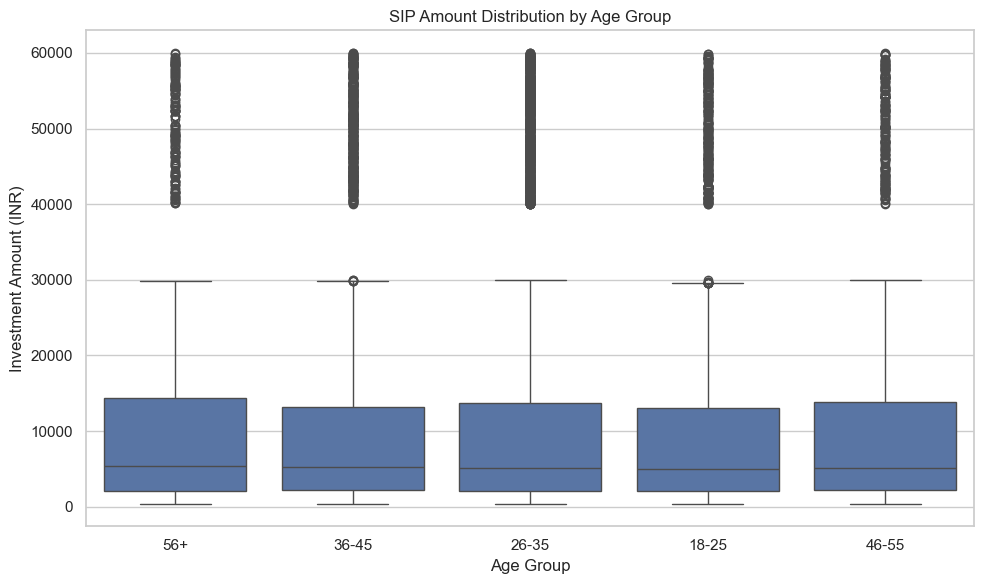

In [22]:
# SIP Amount Distribution by Age Group

sip_txn = transactions[
    transactions["transaction_type"] == "Sip"
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.xlabel("Age Group")
plt.ylabel("Investment Amount (INR)")

plt.tight_layout()

plt.show()

In [23]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title("SIP Amount Distribution by Age Group")

plt.tight_layout()

plt.savefig(
    "../reports/sip_amount_by_age.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("SIP boxplot saved successfully")

SIP boxplot saved successfully


In [24]:
import os
os.listdir("../reports")

['aum_growth.png',
 'category_heatmap.png',
 'gender_distribution.html',
 'investor_age_distribution.html',
 'nav_trend_analysis.html',
 'sip_amount_by_age.png',
 'sip_trend.html']

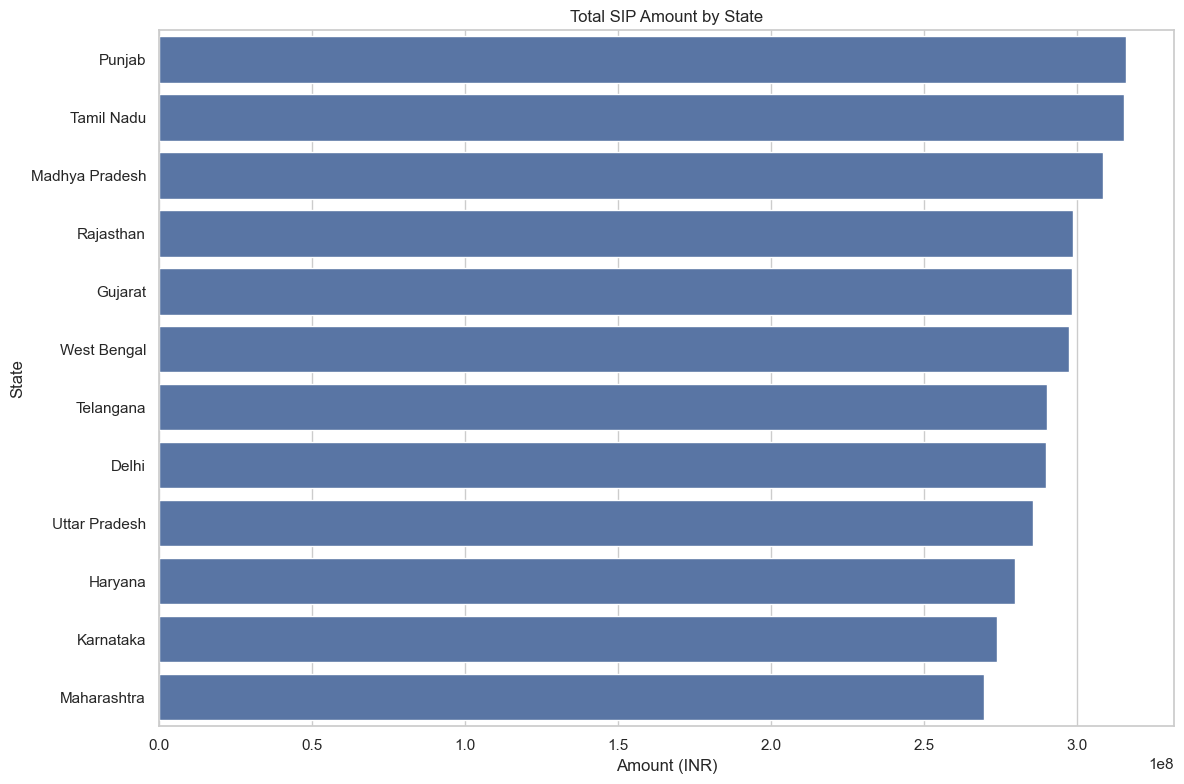

In [25]:
# SIP Amount by State

state_sip = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title("Total SIP Amount by State")
plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.tight_layout()

plt.show()

In [26]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title("Total SIP Amount by State")

plt.tight_layout()

plt.savefig(
    "../reports/state_wise_sip.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

In [27]:
# City Tier Distribution

tier_counts = (
    transactions["city_tier"]
    .value_counts()
    .reset_index()
)

tier_counts.columns = ["city_tier", "count"]

fig = px.pie(
    tier_counts,
    names="city_tier",
    values="count",
    title="T30 vs B30 Investor Distribution"
)

fig.show()

In [28]:
fig.write_html("../reports/t30_b30_distribution.html")

In [29]:
# Folio Growth Trend

folio["month"] = pd.to_datetime(folio["month"])

fig = px.line(
    folio,
    x="month",
    y="total_folios_crore",
    markers=True,
    title="Industry Folio Growth (2022–2025)"
)

fig.show()

In [30]:
fig.write_html("../reports/folio_growth.html")

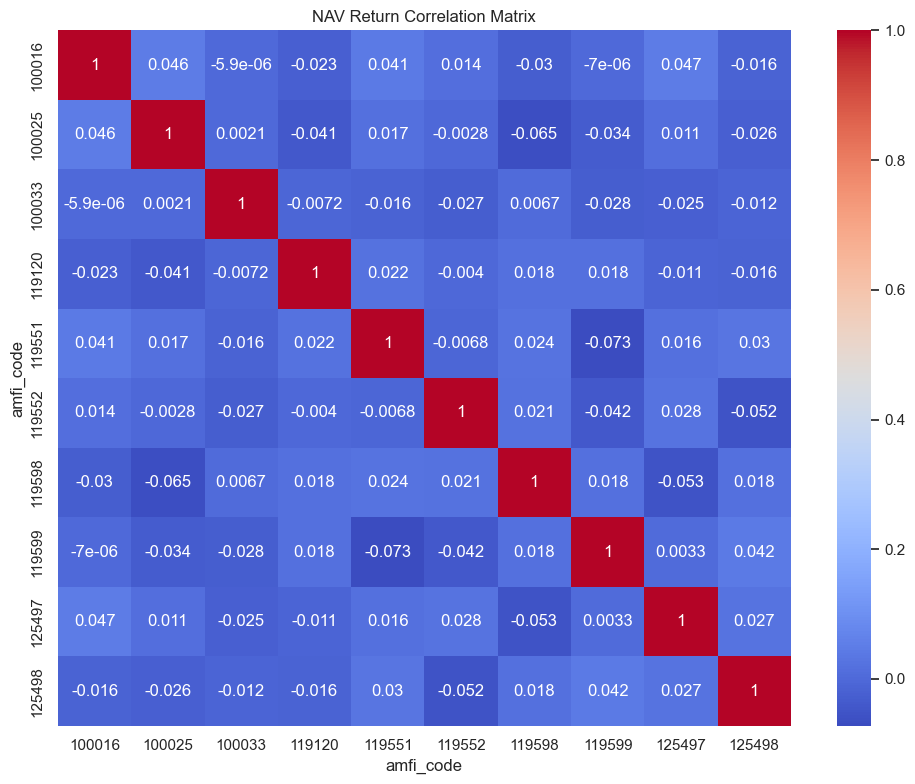

In [31]:
# Select 10 Funds

sample_funds = (
    nav["amfi_code"]
    .unique()[:10]
)

corr_data = nav[
    nav["amfi_code"].isin(sample_funds)
]

pivot_nav = corr_data.pivot_table(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot_nav.pct_change()

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.tight_layout()

plt.show()

In [32]:
plt.savefig(
    "../reports/nav_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [33]:
# Sector Allocation

sector_weights = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .reset_index()
)

fig = px.pie(
    sector_weights,
    names="sector",
    values="weight_pct",
    hole=0.5,
    title="Sector Allocation Across Funds"
)

fig.show()

In [34]:
fig.write_html("../reports/sector_allocation.html")

In [35]:
import os

len(os.listdir("../reports"))

12

### Insight 1
NAV values across most equity mutual funds showed a strong upward trend between 2022 and 2026, reflecting overall market growth.
### Insight 2
The 2023 bull market period resulted in significant NAV appreciation across large-cap and mid-cap schemes.
### Insight 3
A temporary market correction was visible during early 2024, causing short-term NAV fluctuations.
### Insight 4
SBI Mutual Fund consistently maintained the highest AUM among all fund houses, indicating strong investor trust and market leadership.
### Insight 5
Monthly SIP inflows showed a steady upward trend, demonstrating increasing retail investor participation.
### Insight 6
The highest SIP inflow occurred during late 2025, highlighting record investor confidence in mutual funds.
### Insight 7
Certain fund categories consistently attracted higher inflows compared to others, indicating category-specific investor preferences.
### Insight 8
Middle-aged investors formed the largest investor segment across mutual fund transactions.
### Insight 9
Investor participation was concentrated in a few major states, reflecting regional differences in financial awareness and investment adoption.
### Insight 10
Portfolio allocations were concentrated in a limited number of sectors, indicating sector-specific investment strategies among equity funds.


In [36]:
import os

print("Charts Generated:", len(os.listdir("../reports")))
print(os.listdir("../reports"))

Charts Generated: 12
['aum_growth.png', 'category_heatmap.png', 'folio_growth.html', 'gender_distribution.html', 'investor_age_distribution.html', 'nav_correlation_heatmap.png', 'nav_trend_analysis.html', 'sector_allocation.html', 'sip_amount_by_age.png', 'sip_trend.html', 'state_wise_sip.png', 't30_b30_distribution.html']
